In [80]:
import pandas as pd

# cargar aceleraciones
df_a = pd.read_csv("accel_ang2.csv")

# renombrar columnas
df_a = df_a.rename(columns={
    "inertial-6286.188861:estLinearAccelX": "ax",
    "inertial-6286.188861:estLinearAccelX:valid": "aXvalid",
    "inertial-6286.188861:estLinearAccelY": "ay",
    "inertial-6286.188861:estLinearAccelY:valid": "aYvalid",
    "inertial-6286.188861:estLinearAccelZ": "az",
    "inertial-6286.188861:estLinearAccelZ:valid": "aZvalid",
})

# quedarnos solo con datos válidos
df_a = df_a[
    (df_a["aXvalid"] == 1) &
    (df_a["aYvalid"] == 1) &
    (df_a["aZvalid"] == 1)
]

# df_a.drop(["aZvalid", "aYvalid", "aXvalid"], axis=1)

df_a["time_comp"] = df_a["Time"]*1e-8
df_a["time_comp"] = df_a["time_comp"].astype(int)
df_a["time_comp"] 

df_a["dt"] = df_a["Time"].diff() * 1e-9
# df_u

new_order = ['Time', 'ax', 'ay', 'az', 'dt']
df_a = df_a[new_order]

df_a

,Time,ax,ay,az,dt
0,1771622130451376384,0.003816,0.031436,0.061123,NaN
1,1771622130461423872,0.005611,0.017711,0.056661,0.010047
2,1771622130471371776,0.006301,0.036271,0.061147,0.009948
3,1771622130481222400,0.004411,0.005835,0.034826,0.009851
4,1771622130490975232,-0.007199,0.020422,0.042615,0.009753
...,...,...,...,...,...
2863,1771622159080844032,-0.004404,0.000184,0.032671,0.009791
2864,1771622159090539008,-0.005789,0.007724,0.045007,0.009695
2865,1771622159100142592,0.001703,0.001768,0.038660,0.009604
2866,1771622159109651456,-0.007563,0.005440,0.046788,0.009509


In [81]:
import numpy as np


# Inicializar columnas
for col in ["vx", "vy", "vz", "px", "py", "pz"]:
    df_a[col] = 0.0

p = np.zeros(3)
v = np.zeros(3)

# len(df_a)
for k in range(1, len(df_a)):

    dt = df_a.loc[k, "dt"]

    # Si el primer dt es NaN, lo saltamos
    if pd.isna(dt):
        continue

    a = df_a.loc[k, ["ax", "ay", "az"]].values

    # Velocidad
    v = v + a * dt

    # Posición
    p = p + v * dt

    # Guardar en el DataFrame
    df_a.loc[k, ["vx", "vy", "vz"]] = v
    df_a.loc[k, ["px", "py", "pz"]] = p
    
df_a

,Time,ax,ay,az,dt,vx,vy,vz,px,py,pz
0,1771622130451376384,0.003816,0.031436,0.061123,NaN,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000
1,1771622130461423872,0.005611,0.017711,0.056661,0.010047,0.000056,0.000178,0.000569,5.664810e-07,0.000002,0.000006
2,1771622130471371776,0.006301,0.036271,0.061147,0.009948,0.000119,0.000539,0.001178,1.750854e-06,0.000007,0.000017
3,1771622130481222400,0.004411,0.005835,0.034826,0.009851,0.000163,0.000596,0.001521,3.351648e-06,0.000013,0.000032
4,1771622130490975232,-0.007199,0.020422,0.042615,0.009753,0.000092,0.000795,0.001936,4.251768e-06,0.000021,0.000051
...,...,...,...,...,...,...,...,...,...,...,...
2863,1771622159080844032,-0.004404,0.000184,0.032671,0.009791,0.141787,0.104645,1.220248,3.947801e+00,3.034907,18.024576
2864,1771622159090539008,-0.005789,0.007724,0.045007,0.009695,0.141731,0.104720,1.220685,3.949175e+00,3.035922,18.036410
2865,1771622159100142592,0.001703,0.001768,0.038660,0.009604,0.141747,0.104737,1.221056,3.950536e+00,3.036928,18.048137
2866,1771622159109651456,-0.007563,0.005440,0.046788,0.009509,0.141675,0.104789,1.221501,3.951883e+00,3.037924,18.059752


In [82]:
import matplotlib.pyplot as plt

# Tiempo relativo en segundos
t = (df_a["Time"] - df_a["Time"].iloc[0]) * 1e-9

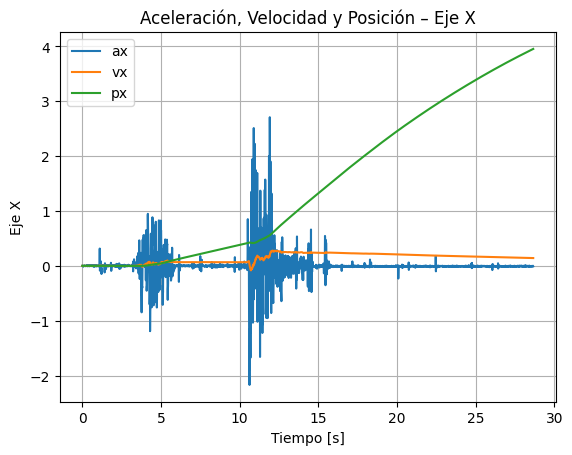

In [83]:
plt.figure()
plt.plot(t, df_a["ax"], label="ax")
plt.plot(t, df_a["vx"], label="vx")
plt.plot(t, df_a["px"], label="px")
plt.xlabel("Tiempo [s]")
plt.ylabel("Eje X")
plt.legend()
plt.grid(True)
plt.title("Aceleración, Velocidad y Posición – Eje X")
plt.show()


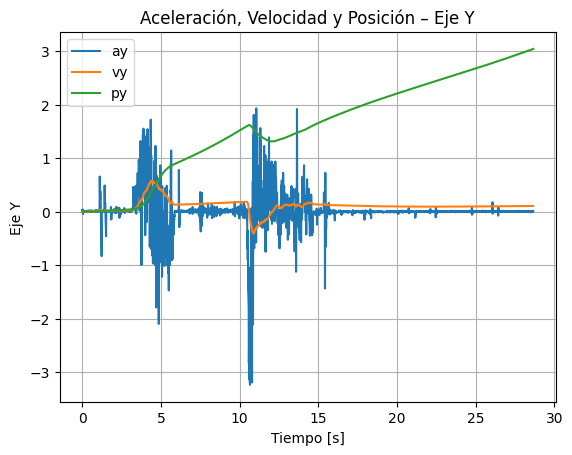

In [84]:
plt.figure()
plt.plot(t, df_a["ay"], label="ay")
plt.plot(t, df_a["vy"], label="vy")
plt.plot(t, df_a["py"], label="py")
plt.xlabel("Tiempo [s]")
plt.ylabel("Eje Y")
plt.legend()
plt.grid(True)
plt.title("Aceleración, Velocidad y Posición – Eje Y")
plt.show()


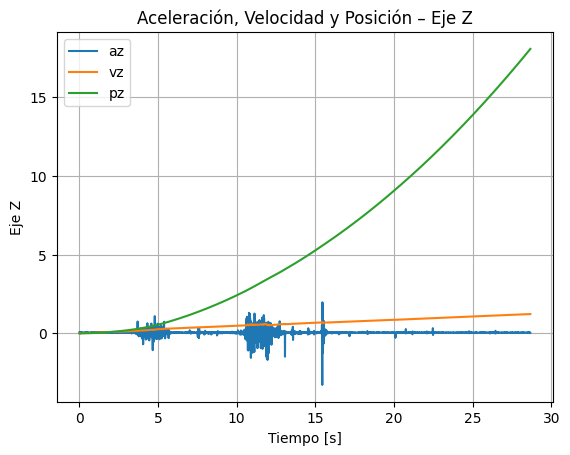

In [85]:
plt.figure()
plt.plot(t, df_a["az"], label="az")
plt.plot(t, df_a["vz"], label="vz")
plt.plot(t, df_a["pz"], label="pz")
plt.xlabel("Tiempo [s]")
plt.ylabel("Eje Z")
plt.legend()
plt.grid(True)
plt.title("Aceleración, Velocidad y Posición – Eje Z")
plt.show()


In [86]:
import pandas as pd


# --- cargar cuaterniones ---
df_q = pd.read_csv("cuaterniones_5.csv")

df_q = df_q.rename(columns={
    "inertial-6286.188861:estOrientQuaternion[0-0]": "q0",
    "inertial-6286.188861:estOrientQuaternion[0-1]": "q1",
    "inertial-6286.188861:estOrientQuaternion[0-2]": "q2",
    "inertial-6286.188861:estOrientQuaternion[0-3]": "q3",
    "inertial-6286.188861:estOrientQuaternion:valid": "qValid",
})

# Comprobar si es un valor válido
# df_q = df_q[df_q["inertial-6286.188861:estOrientQuaternion:valid"] == 1]

# df_q["dt"] = df_q["Time"].diff() * 1e-9
# print(df_q)

df_q["time_comp"] = df_q["Time"] * 1e-6
df_q["time_comp"] = df_q["time_comp"].astype(int)
# df_q["time_comp"]

# df_q["dt"] = df_q["Time"].diff() * 1e-9
# df_u

df_q

,Time,q0,q1,q2,q3,qValid,time_comp
0,1772485620658900224,1.000000,0.000870,0.000118,0.000155,1,1772485620658
1,1772485620669614336,1.000000,0.000886,0.000116,0.000155,1,1772485620669
2,1772485620680224256,1.000000,0.000912,0.000116,0.000154,1,1772485620680
3,1772485620690732288,1.000000,0.000947,0.000121,0.000156,1,1772485620690
4,1772485620701137664,1.000000,0.000984,0.000127,0.000154,1,1772485620701
...,...,...,...,...,...,...,...
6513,1772485685790956288,0.999999,0.000980,-0.000149,0.000295,1,1772485685790
6514,1772485685800697088,0.999999,0.000983,-0.000146,0.000294,1,1772485685800
6515,1772485685810343424,0.999999,0.000985,-0.000143,0.000293,1,1772485685810
6516,1772485685819896320,0.999999,0.000985,-0.000142,0.000293,1,1772485685819


In [87]:
# dt = df_q['dt'].dropna().values
# fs_est = 1 / np.mean(dt)

# print("fs estimada:", fs_est, "Hz")

In [88]:
# cargar aceleraciones
df_a = pd.read_csv("accel_ang_5.csv")

# renombrar columnas
df_a = df_a.rename(columns={
    "inertial-6286.188861:estAngularRateX": "arx",
    "inertial-6286.188861:estAngularRateX:valid": "arXvalid",
    "inertial-6286.188861:estAngularRateY": "ary",
    "inertial-6286.188861:estAngularRateY:valid": "arYvalid",
    "inertial-6286.188861:estAngularRateZ": "arz",
    "inertial-6286.188861:estAngularRateZ:valid": "alZvalid",
    "inertial-6286.188861:estLinearAccelX": "alx",
    "inertial-6286.188861:estLinearAccelX:valid": "alXvalid",
    "inertial-6286.188861:estLinearAccelY": "aly",
    "inertial-6286.188861:estLinearAccelY:valid": "alYvalid",
    "inertial-6286.188861:estLinearAccelZ": "alz",
    "inertial-6286.188861:estLinearAccelZ:valid": "alZvalid",
})

# quedarnos solo con datos válidos
# df_a = df_a[
#     (df_a["arXvalid"] == 1) &
#     (df_a["arYvalid"] == 1) &
#     (df_a["arZvalid"] == 1)
# ]

# df_a.drop(["aZvalid", "aYvalid", "aXvalid"], axis=1)

df_a["time_comp"] = df_a["Time"]*1e-6
df_a["time_comp"] = df_a["time_comp"].astype(int)
# df_a["time_comp"] 

# df_a["dt"] = df_a["Time"].diff() * 1e-9

df_a

,Time,alx,alXvalid,aly,alYvalid,alz,alZvalid,arx,arXvalid,ary,arYvalid,arz,alZvalid,time_comp
0,1772485620658900224,0.000187,1,0.003232,1,-0.041247,1,-0.001130,1,-0.000910,1,0.000174,1,1772485620658
1,1772485620669614336,-0.000500,1,-0.000079,1,-0.053335,1,0.000955,1,-0.000626,1,0.000041,1,1772485620669
2,1772485620680224256,-0.006569,1,-0.010355,1,-0.048097,1,0.002938,1,-0.000271,1,-0.000032,1,1772485620680
3,1772485620690732288,-0.014657,1,0.001652,1,-0.028988,1,0.004779,1,0.000315,1,0.000127,1,1772485620690
4,1772485620701137664,-0.016874,1,0.003646,1,-0.004417,1,0.005844,1,0.000742,1,-0.000032,1,1772485620701
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6513,1772485685790956288,0.002915,1,0.002639,1,0.043796,1,-0.000063,1,0.000050,1,0.000054,1,1772485685790
6514,1772485685800697088,0.000611,1,0.000804,1,0.047965,1,0.000272,1,0.000207,1,-0.000029,1,1772485685800
6515,1772485685810343424,0.004141,1,-0.002980,1,0.049031,1,0.000346,1,0.000376,1,-0.000101,1,1772485685810
6516,1772485685819896320,0.004177,1,-0.002305,1,0.042784,1,0.000254,1,0.000320,1,-0.000035,1,1772485685819


In [89]:
# dt = df_a['dt'].dropna().values
# fs_est = 1 / np.mean(dt)

# print("fs estimada:", fs_est, "Hz")

In [90]:
# import pandas as pd

# # Cargar datos
# data = pd.read_csv("imu_data.csv")

# # Eliminar primera fila (dt = NaN)
# data = data.dropna().reset_index(drop=True)

arx = df_a['arx'].values
ary = df_a['ary'].values
arz = df_a['arz'].values
alx = df_a['alx'].values
aly = df_a['aly'].values
alz = df_a['alz'].values

ang_acc = np.vstack((arx, ary, arz, alx, aly, alz)).T

ang_acc

array([[-1.13044889e-03, -9.09986091e-04,  1.74146495e-04,
         1.86768011e-04,  3.23166931e-03, -4.12468389e-02],
       [ 9.55355703e-04, -6.26094581e-04,  4.12790760e-05,
        -5.00068592e-04, -7.90262129e-05, -5.33353500e-02],
       [ 2.93758116e-03, -2.71116325e-04, -3.17097365e-05,
        -6.56937063e-03, -1.03553375e-02, -4.80969287e-02],
       ...,
       [ 3.46021581e-04,  3.76196636e-04, -1.01066646e-04,
         4.14140569e-03, -2.97962711e-03,  4.90310714e-02],
       [ 2.54287763e-04,  3.19740444e-04, -3.48197136e-05,
         4.17662971e-03, -2.30454979e-03,  4.27837074e-02],
       [ 1.64357873e-04,  2.36561435e-04, -1.45496684e-04,
         5.72216930e-03, -1.57696439e-03,  4.44397368e-02]],
      shape=(6518, 6))

In [91]:
import numpy as np
from scipy.signal import butter, sosfilt

fs = 100.0      # Hz
fc = 10.0       # Hz
order = 4

Wn = fc / (fs / 2)

sos = butter(order, Wn, btype='low', output='sos')
print(sos)

accel_filt = sosfilt(sos, ang_acc, axis=0)
accel_filt

[[ 0.00482434  0.00964869  0.00482434  1.         -1.04859958  0.29614036]
 [ 1.          2.          1.          1.         -1.32091343  0.63273879]]


array([[-5.45367358e-06, -4.39008535e-06,  8.40142486e-07,
         9.01033014e-07,  1.55906824e-05, -1.98988913e-04],
       [-3.01282809e-05, -3.09832010e-05,  5.55044293e-06,
         3.32663891e-06,  9.89238046e-05, -1.52477051e-03],
       [-5.88839015e-05, -1.02986942e-04,  1.68922207e-05,
        -3.01391776e-05,  2.40385975e-04, -5.60770727e-03],
       ...,
       [-1.26136167e-05,  2.20535470e-04, -3.43096424e-05,
         2.30314855e-03,  2.70233581e-04,  4.41812119e-02],
       [-2.82826203e-05,  2.19067024e-04, -3.58460532e-05,
         2.36486619e-03,  5.29819543e-04,  4.35796484e-02],
       [ 9.48062515e-06,  2.16448375e-04, -3.75383767e-05,
         2.43493838e-03,  4.86958234e-04,  4.35869165e-02]],
      shape=(6518, 6))

In [92]:
from scipy.signal import butter, filtfilt

def butter_lowpass(fc, fs, order=4):
    wn = fc / (fs / 2)
    b, a = butter(order, wn, btype='low')
    return b, a

fc = 10  # Hz
b, a = butter_lowpass(fc, fs, order=4)

arx_f = filtfilt(b, a, arx)
ary_f = filtfilt(b, a, ary)
arz_f = filtfilt(b, a, arz)
alx_f = filtfilt(b, a, alx)
aly_f = filtfilt(b, a, aly)
alz_f = filtfilt(b, a, alz)
arx_f

array([-0.00112747,  0.00113059,  0.0031449 , ...,  0.00013963,
        0.00015868,  0.00016773], shape=(6518,))

In [93]:
arx

array([-0.00113045,  0.00095536,  0.00293758, ...,  0.00034602,
        0.00025429,  0.00016436], shape=(6518,))

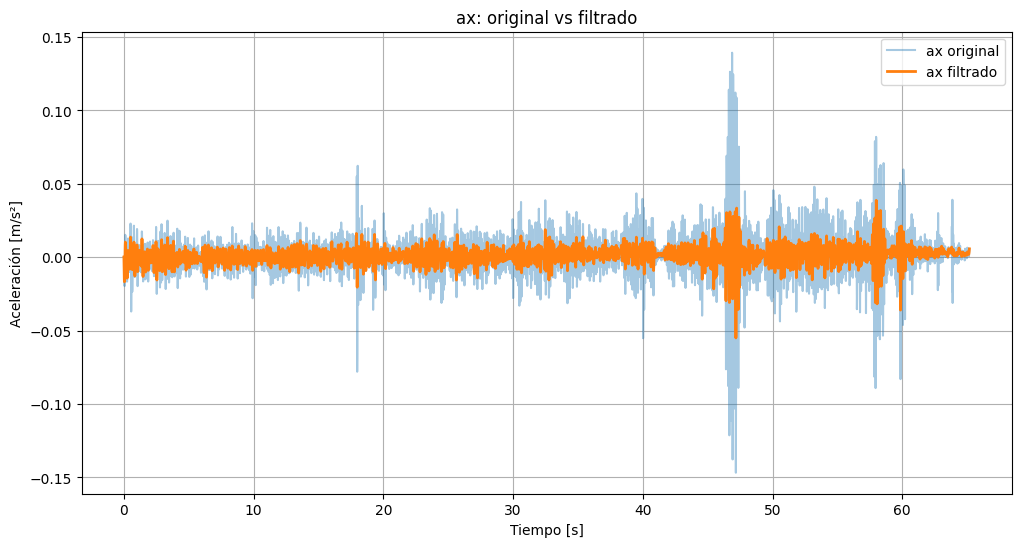

In [94]:
import matplotlib.pyplot as plt

# t = np.cumsum(dt)
N = len(alx)
t = np.arange(N) / fs

plt.figure(figsize=(12,6))
plt.plot(t, alx, label='ax original', alpha=0.4)
plt.plot(t, alx_f, label='ax filtrado', linewidth=2)
plt.xlabel("Tiempo [s]")
plt.ylabel("Aceleración [m/s²]")
plt.title("ax: original vs filtrado")
plt.legend()
plt.grid()
plt.show()

In [95]:
print(alx_f.shape)
df_a['arx']

(6518,)


0      -0.001130
1       0.000955
2       0.002938
3       0.004779
4       0.005844
          ...   
6513   -0.000063
6514    0.000272
6515    0.000346
6516    0.000254
6517    0.000164
Name: arx, Length: 6518, dtype: float64

In [96]:
# print(arx_f.shape)
# df_a['arx']
df_a['arx_f'] = arx_f
df_a['ary_f'] = ary_f
df_a['arz_f'] = arz_f
df_a['alx_f'] = alx_f
df_a['aly_f'] = aly_f
df_a['alz_f'] = alz_f
df_a

,Time,alx,alXvalid,aly,alYvalid,alz,alZvalid,arx,arXvalid,ary,arYvalid,arz,alZvalid,time_comp,arx_f,ary_f,arz_f,alx_f,aly_f,alz_f
0,1772485620658900224,0.000187,1,0.003232,1,-0.041247,1,-0.001130,1,-0.000910,1,0.000174,1,1772485620658,-0.001127,-0.000906,0.000175,0.000123,0.003207,-0.041210
1,1772485620669614336,-0.000500,1,-0.000079,1,-0.053335,1,0.000955,1,-0.000626,1,0.000041,1,1772485620669,0.001131,-0.000497,0.000097,-0.006001,0.001983,-0.037868
2,1772485620680224256,-0.006569,1,-0.010355,1,-0.048097,1,0.002938,1,-0.000271,1,-0.000032,1,1772485620680,0.003145,-0.000098,0.000016,-0.011334,0.000894,-0.030269
3,1772485620690732288,-0.014657,1,0.001652,1,-0.028988,1,0.004779,1,0.000315,1,0.000127,1,1772485620690,0.004702,0.000278,-0.000069,-0.015121,-0.000025,-0.015691
4,1772485620701137664,-0.016874,1,0.003646,1,-0.004417,1,0.005844,1,0.000742,1,-0.000032,1,1772485620701,0.005644,0.000615,-0.000152,-0.016716,-0.000851,0.006163
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6513,1772485685790956288,0.002915,1,0.002639,1,0.043796,1,-0.000063,1,0.000050,1,0.000054,1,1772485685790,0.000068,0.000225,-0.000029,0.002206,0.000220,0.044236
6514,1772485685800697088,0.000611,1,0.000804,1,0.047965,1,0.000272,1,0.000207,1,-0.000029,1,1772485685800,0.000107,0.000230,-0.000044,0.002680,-0.000115,0.044394
6515,1772485685810343424,0.004141,1,-0.002980,1,0.049031,1,0.000346,1,0.000376,1,-0.000101,1,1772485685810,0.000140,0.000232,-0.000070,0.003455,-0.000564,0.044513
6516,1772485685819896320,0.004177,1,-0.002305,1,0.042784,1,0.000254,1,0.000320,1,-0.000035,1,1772485685819,0.000159,0.000233,-0.000104,0.004500,-0.001067,0.044522


In [97]:
df_q

,Time,q0,q1,q2,q3,qValid,time_comp
0,1772485620658900224,1.000000,0.000870,0.000118,0.000155,1,1772485620658
1,1772485620669614336,1.000000,0.000886,0.000116,0.000155,1,1772485620669
2,1772485620680224256,1.000000,0.000912,0.000116,0.000154,1,1772485620680
3,1772485620690732288,1.000000,0.000947,0.000121,0.000156,1,1772485620690
4,1772485620701137664,1.000000,0.000984,0.000127,0.000154,1,1772485620701
...,...,...,...,...,...,...,...
6513,1772485685790956288,0.999999,0.000980,-0.000149,0.000295,1,1772485685790
6514,1772485685800697088,0.999999,0.000983,-0.000146,0.000294,1,1772485685800
6515,1772485685810343424,0.999999,0.000985,-0.000143,0.000293,1,1772485685810
6516,1772485685819896320,0.999999,0.000985,-0.000142,0.000293,1,1772485685819


In [98]:
df_a

,Time,alx,alXvalid,aly,alYvalid,alz,alZvalid,arx,arXvalid,ary,arYvalid,arz,alZvalid,time_comp,arx_f,ary_f,arz_f,alx_f,aly_f,alz_f
0,1772485620658900224,0.000187,1,0.003232,1,-0.041247,1,-0.001130,1,-0.000910,1,0.000174,1,1772485620658,-0.001127,-0.000906,0.000175,0.000123,0.003207,-0.041210
1,1772485620669614336,-0.000500,1,-0.000079,1,-0.053335,1,0.000955,1,-0.000626,1,0.000041,1,1772485620669,0.001131,-0.000497,0.000097,-0.006001,0.001983,-0.037868
2,1772485620680224256,-0.006569,1,-0.010355,1,-0.048097,1,0.002938,1,-0.000271,1,-0.000032,1,1772485620680,0.003145,-0.000098,0.000016,-0.011334,0.000894,-0.030269
3,1772485620690732288,-0.014657,1,0.001652,1,-0.028988,1,0.004779,1,0.000315,1,0.000127,1,1772485620690,0.004702,0.000278,-0.000069,-0.015121,-0.000025,-0.015691
4,1772485620701137664,-0.016874,1,0.003646,1,-0.004417,1,0.005844,1,0.000742,1,-0.000032,1,1772485620701,0.005644,0.000615,-0.000152,-0.016716,-0.000851,0.006163
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6513,1772485685790956288,0.002915,1,0.002639,1,0.043796,1,-0.000063,1,0.000050,1,0.000054,1,1772485685790,0.000068,0.000225,-0.000029,0.002206,0.000220,0.044236
6514,1772485685800697088,0.000611,1,0.000804,1,0.047965,1,0.000272,1,0.000207,1,-0.000029,1,1772485685800,0.000107,0.000230,-0.000044,0.002680,-0.000115,0.044394
6515,1772485685810343424,0.004141,1,-0.002980,1,0.049031,1,0.000346,1,0.000376,1,-0.000101,1,1772485685810,0.000140,0.000232,-0.000070,0.003455,-0.000564,0.044513
6516,1772485685819896320,0.004177,1,-0.002305,1,0.042784,1,0.000254,1,0.000320,1,-0.000035,1,1772485685819,0.000159,0.000233,-0.000104,0.004500,-0.001067,0.044522


In [99]:
df_u = pd.merge(
    df_q,
    df_a,
    on="time_comp",
    how="inner"
)
df_u

,Time_x,q0,q1,q2,q3,qValid,time_comp,Time_y,alx,alXvalid,...,ary,arYvalid,arz,alZvalid,arx_f,ary_f,arz_f,alx_f,aly_f,alz_f
0,1772485620658900224,1.000000,0.000870,0.000118,0.000155,1,1772485620658,1772485620658900224,0.000187,1,...,-0.000910,1,0.000174,1,-0.001127,-0.000906,0.000175,0.000123,0.003207,-0.041210
1,1772485620669614336,1.000000,0.000886,0.000116,0.000155,1,1772485620669,1772485620669614336,-0.000500,1,...,-0.000626,1,0.000041,1,0.001131,-0.000497,0.000097,-0.006001,0.001983,-0.037868
2,1772485620680224256,1.000000,0.000912,0.000116,0.000154,1,1772485620680,1772485620680224256,-0.006569,1,...,-0.000271,1,-0.000032,1,0.003145,-0.000098,0.000016,-0.011334,0.000894,-0.030269
3,1772485620690732288,1.000000,0.000947,0.000121,0.000156,1,1772485620690,1772485620690732288,-0.014657,1,...,0.000315,1,0.000127,1,0.004702,0.000278,-0.000069,-0.015121,-0.000025,-0.015691
4,1772485620701137664,1.000000,0.000984,0.000127,0.000154,1,1772485620701,1772485620701137664,-0.016874,1,...,0.000742,1,-0.000032,1,0.005644,0.000615,-0.000152,-0.016716,-0.000851,0.006163
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6513,1772485685790956288,0.999999,0.000980,-0.000149,0.000295,1,1772485685790,1772485685790956288,0.002915,1,...,0.000050,1,0.000054,1,0.000068,0.000225,-0.000029,0.002206,0.000220,0.044236
6514,1772485685800697088,0.999999,0.000983,-0.000146,0.000294,1,1772485685800,1772485685800697088,0.000611,1,...,0.000207,1,-0.000029,1,0.000107,0.000230,-0.000044,0.002680,-0.000115,0.044394
6515,1772485685810343424,0.999999,0.000985,-0.000143,0.000293,1,1772485685810,1772485685810343424,0.004141,1,...,0.000376,1,-0.000101,1,0.000140,0.000232,-0.000070,0.003455,-0.000564,0.044513
6516,1772485685819896320,0.999999,0.000985,-0.000142,0.000293,1,1772485685819,1772485685819896320,0.004177,1,...,0.000320,1,-0.000035,1,0.000159,0.000233,-0.000104,0.004500,-0.001067,0.044522


In [100]:
df_u = df_u.rename(columns={"Time_x": "time"})
df_u.drop(["Time_y"], axis=1, inplace=True)
# df_u

df_u["dt"] = df_u["time"].diff() * 1e-9
# df_u

new_order = ['time', 'q0', 'q1', 'q2', 'q3', 'arx', 'ary', 'arz', 'alx', 'aly', 'alz','dt', 'arx_f', 'ary_f', 'arz_f', 'alx_f', 'aly_f', 'alz_f']
df_u = df_u[new_order]
# print(df_u)
df_u

,time,q0,q1,q2,q3,arx,ary,arz,alx,aly,alz,dt,arx_f,ary_f,arz_f,alx_f,aly_f,alz_f
0,1772485620658900224,1.000000,0.000870,0.000118,0.000155,-0.001130,-0.000910,0.000174,0.000187,0.003232,-0.041247,NaN,-0.001127,-0.000906,0.000175,0.000123,0.003207,-0.041210
1,1772485620669614336,1.000000,0.000886,0.000116,0.000155,0.000955,-0.000626,0.000041,-0.000500,-0.000079,-0.053335,0.010714,0.001131,-0.000497,0.000097,-0.006001,0.001983,-0.037868
2,1772485620680224256,1.000000,0.000912,0.000116,0.000154,0.002938,-0.000271,-0.000032,-0.006569,-0.010355,-0.048097,0.010610,0.003145,-0.000098,0.000016,-0.011334,0.000894,-0.030269
3,1772485620690732288,1.000000,0.000947,0.000121,0.000156,0.004779,0.000315,0.000127,-0.014657,0.001652,-0.028988,0.010508,0.004702,0.000278,-0.000069,-0.015121,-0.000025,-0.015691
4,1772485620701137664,1.000000,0.000984,0.000127,0.000154,0.005844,0.000742,-0.000032,-0.016874,0.003646,-0.004417,0.010405,0.005644,0.000615,-0.000152,-0.016716,-0.000851,0.006163
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6513,1772485685790956288,0.999999,0.000980,-0.000149,0.000295,-0.000063,0.000050,0.000054,0.002915,0.002639,0.043796,0.009837,0.000068,0.000225,-0.000029,0.002206,0.000220,0.044236
6514,1772485685800697088,0.999999,0.000983,-0.000146,0.000294,0.000272,0.000207,-0.000029,0.000611,0.000804,0.047965,0.009741,0.000107,0.000230,-0.000044,0.002680,-0.000115,0.044394
6515,1772485685810343424,0.999999,0.000985,-0.000143,0.000293,0.000346,0.000376,-0.000101,0.004141,-0.002980,0.049031,0.009646,0.000140,0.000232,-0.000070,0.003455,-0.000564,0.044513
6516,1772485685819896320,0.999999,0.000985,-0.000142,0.000293,0.000254,0.000320,-0.000035,0.004177,-0.002305,0.042784,0.009553,0.000159,0.000233,-0.000104,0.004500,-0.001067,0.044522


In [101]:
# solo como comprobación

import numpy as np

dt = df_u['dt'].dropna().values
fs_est = 1 / np.mean(dt)

print("fs estimada:", fs_est, "Hz")

fs estimada: 99.99930216230422 Hz


In [102]:
import numpy as np

# Inicializar columnas
for col in ["vx", "vy", "vz", "px", "py", "pz"]:
    df_u[col] = 0.0

p = np.zeros(3)
v = np.ones(3)

# Umbrales
ACC_TH = 0.1       # m/s^2
GYRO_TH = np.deg2rad(1.0)  # rad/s

print(v.shape)
print(df_u.loc[k, ["vx", "vy", "vz"]].shape)
# len(df_a)

a = df_u.loc[2, ["alx", "aly", "alz"]].values
a.shape

v.shape
dt = 0.01
# np.zeros(3).shape

a = df_u.loc[2, ["alx", "aly", "alz"]].values.copy()
print(type(a), a.shape)
a[1] = 0.0
print(a[1], a.flags)

arr_1d = np.array([1, 2, 3, 4, 5])
print(arr_1d.shape)
arr_1d[2] = 99  # Modifies the third element (index 2)
print(arr_1d)


print(v, v.shape)
v[1] = 0
print(v, v.shape)

x = v + a#*dt
x

(3,)
(3,)
<class 'numpy.ndarray'> (3,)
0.0   C_CONTIGUOUS : True
  F_CONTIGUOUS : True
  OWNDATA : True
  WRITEABLE : True
  ALIGNED : True
  WRITEBACKIFCOPY : False

(5,)
[ 1  2 99  4  5]
[1. 1. 1.] (3,)
[1. 0. 1.] (3,)


array([0.99343063, 0.        , 0.95190307])

In [103]:
# a = df_a.loc[3, ["alx", "aly", "alz"]].values
# a

In [104]:
# def zupt_acc_ang(a, g, v):
#     if np.linalg.norm(a) < ACC_TH and np.linalg.norm(g) < GYRO_TH:
#         v = np.zeros(3)   # ZUPT duro

In [105]:
# ACC_TH_ENERGY = (0.02**2)*3 # = 0.0012

[[ 0.00012289  0.00320695 -0.04121041]
 [-0.00600064  0.00198315 -0.03786842]
 [-0.01133408  0.00089369 -0.03026912]
 ...
 [ 0.00345522 -0.00056413  0.0445132 ]
 [ 0.00449976 -0.00106656  0.04452153]
 [ 0.00570899 -0.00157976  0.04443733]]


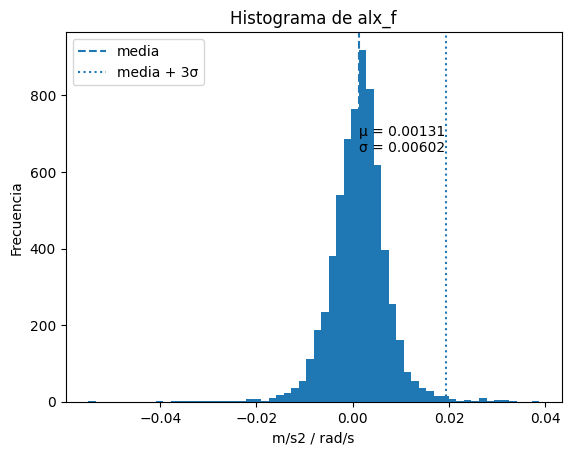

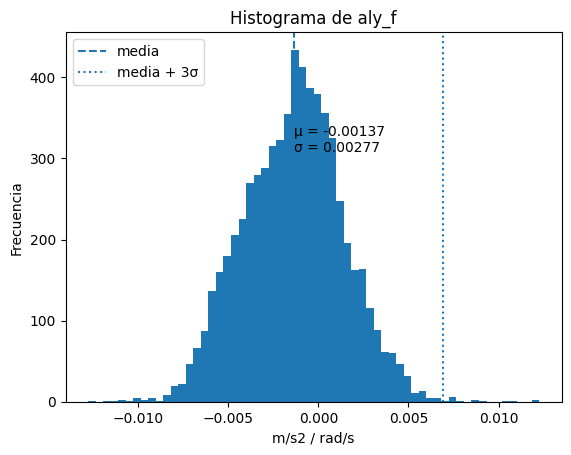

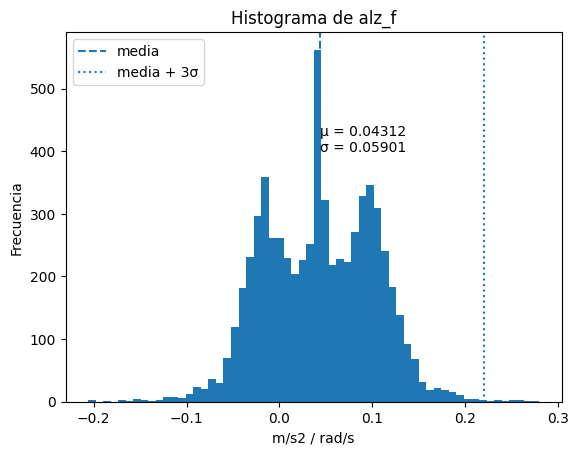

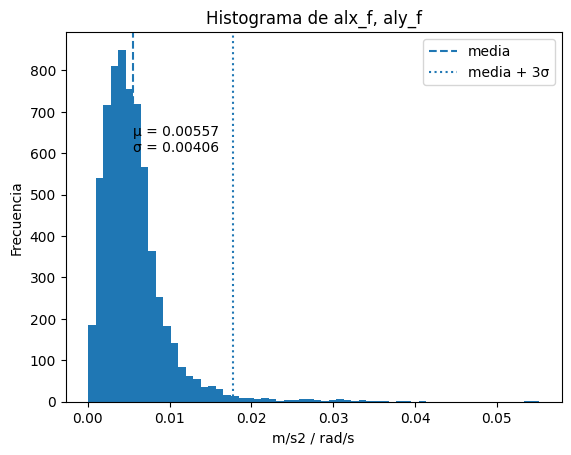

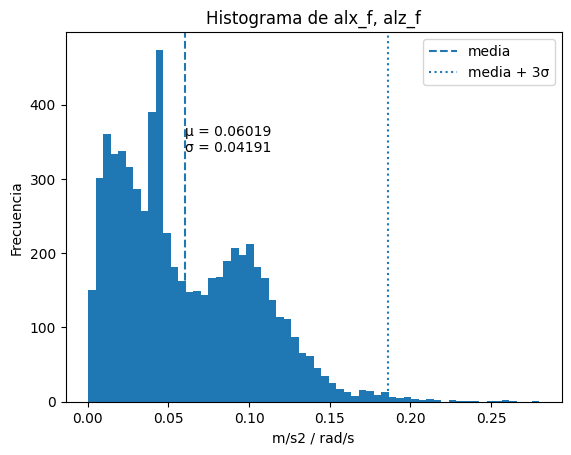

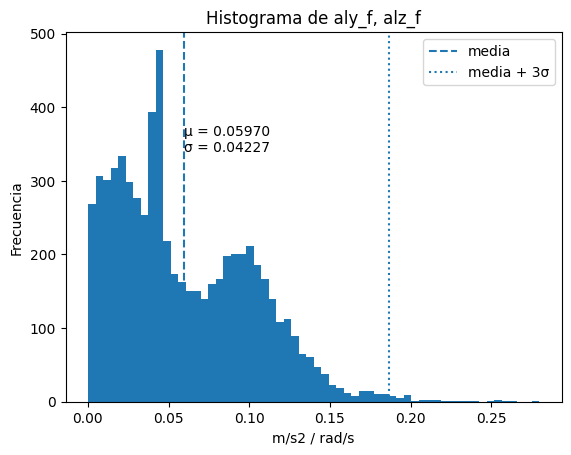

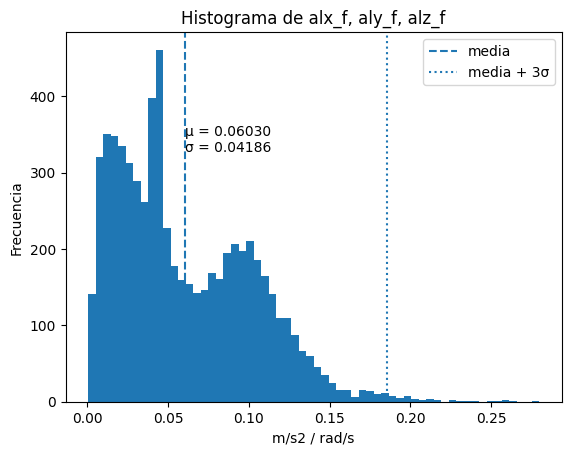

In [106]:
# segun prueba obtener umbrales y ganancias
import numpy as np
import matplotlib.pyplot as plt

accl = df_u[["alx_f", "aly_f", "alz_f"]].values#.copy()
print(accl)
gyro = df_u[["arx_f", "ary_f", "arz_f"]].values

def histogramaUnEje(axis):
    axis_values = df_u[axis].values
    # axis_values = np.linalg.norm(axis_values)

    axis_mean  = np.mean(axis_values)
    axis_std   = np.std(axis_values)

    plt.figure()
    plt.hist(axis_values, bins=60)

    plt.axvline(axis_mean, linestyle='--', label='media')
    plt.axvline(axis_mean + 3*axis_std, linestyle=':', label='media + 3σ')

    # Texto dentro de la gráfica
    plt.text(
        axis_mean,
        plt.ylim()[1]*0.75,
        f"μ = {axis_mean:.5f}\nσ = {axis_std:.5f}",
        verticalalignment='top'
    )

    plt.xlabel("m/s2 / rad/s")
    plt.ylabel("Frecuencia")
    plt.title(f"Histograma de {axis}")
    plt.legend()

def histogramaDosEjes(axis1, axis2):
    axis_values = df_u[[axis1, axis2]].values
    axis_norm  = np.linalg.norm(axis_values, axis=1)

    axis_mean  = np.mean(axis_norm)
    axis_std   = np.std(axis_norm)

    plt.figure()
    plt.hist(axis_norm, bins=60)

    plt.axvline(axis_mean, linestyle='--', label='media')
    plt.axvline(axis_mean + 3*axis_std, linestyle=':', label='media + 3σ')

    # Texto dentro de la gráfica
    plt.text(
        axis_mean,
        plt.ylim()[1]*0.75,
        f"μ = {axis_mean:.5f}\nσ = {axis_std:.5f}",
        verticalalignment='top'
    )

    plt.xlabel("m/s2 / rad/s")
    plt.ylabel("Frecuencia")
    plt.title(f"Histograma de {axis1}, {axis2}")
    plt.legend()

def histogramaTresEjes(axis1, axis2, axis3):
    axis_values = df_u[[axis1, axis2, axis3]].values
    axis_norm  = np.linalg.norm(axis_values, axis=1)

    axis_mean  = np.mean(axis_norm)
    axis_std   = np.std(axis_norm)

    plt.figure()
    plt.hist(axis_norm, bins=60)

    plt.axvline(axis_mean, linestyle='--', label='media')
    plt.axvline(axis_mean + 3*axis_std, linestyle=':', label='media + 3σ')

    # Texto dentro de la gráfica
    plt.text(
        axis_mean,
        plt.ylim()[1]*0.75,
        f"μ = {axis_mean:.5f}\nσ = {axis_std:.5f}",
        verticalalignment='top'
    )

    plt.xlabel("m/s2 / rad/s")
    plt.ylabel("Frecuencia")
    plt.title(f"Histograma de {axis1}, {axis2}, {axis3}")
    plt.legend()

histogramaUnEje("alx_f")
histogramaUnEje("aly_f")
histogramaUnEje("alz_f")
histogramaDosEjes("alx_f", "aly_f")
histogramaDosEjes("alx_f", "alz_f")
histogramaDosEjes("aly_f", "alz_f")
histogramaTresEjes("alx_f", "aly_f", "alz_f")


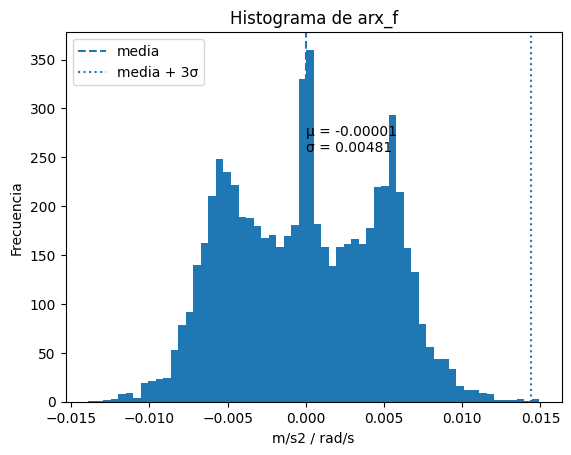

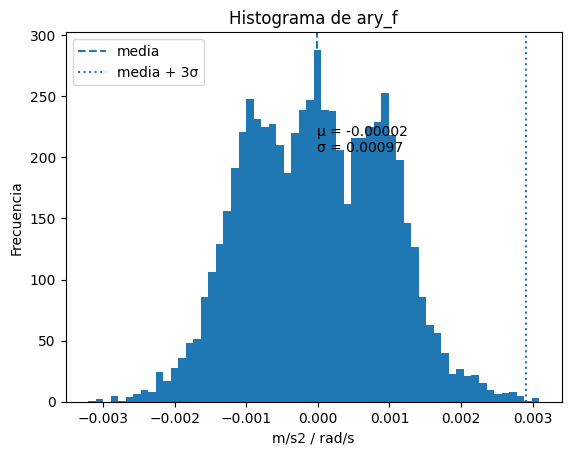

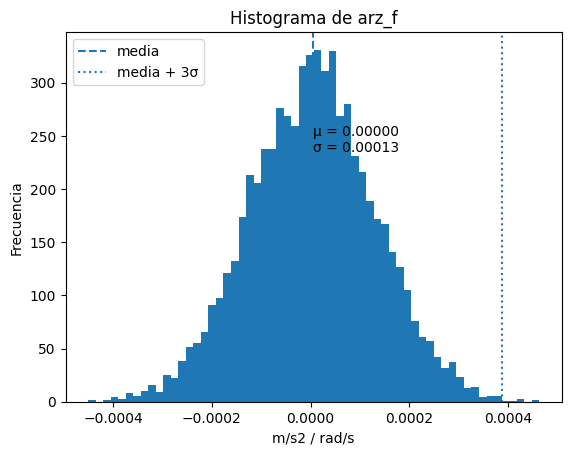

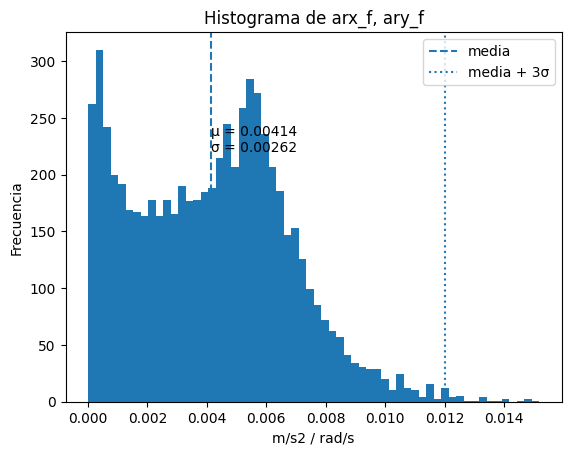

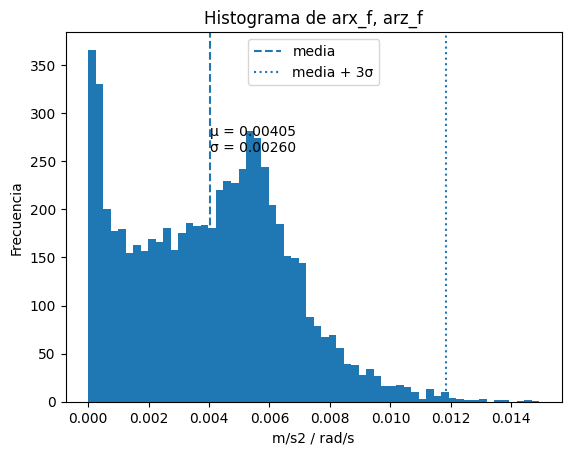

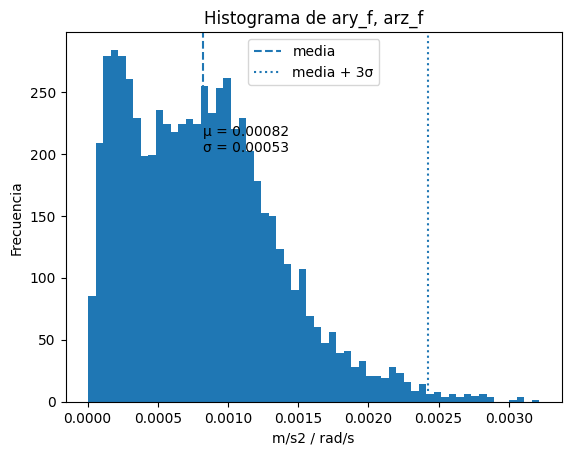

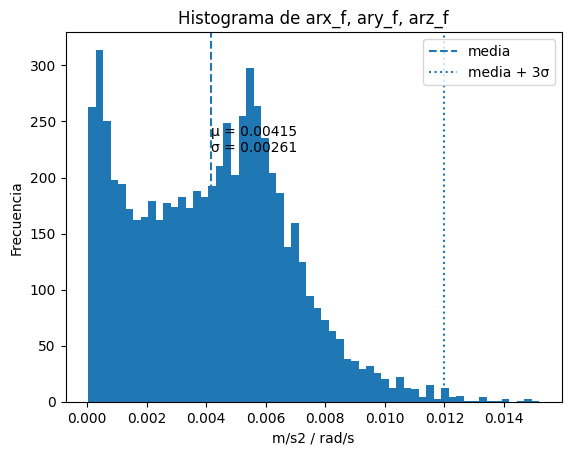

In [107]:
histogramaUnEje("arx_f")
histogramaUnEje("ary_f")
histogramaUnEje("arz_f")
histogramaDosEjes("arx_f", "ary_f")
histogramaDosEjes("arx_f", "arz_f")
histogramaDosEjes("ary_f", "arz_f")
histogramaTresEjes("arx_f", "ary_f", "arz_f")

In [108]:
from scipy.spatial.transform import Rotation as R

p = np.zeros(3)
v = np.zeros(3)
v_body = np.zeros(3)

for k in range(0, len(df_u)):

    # dt = df_a.loc[k, "dt"]
    dt = 0.01

    # Si el primer dt es NaN, lo saltamos
    if pd.isna(dt):
        continue

    a_body = df_u.loc[k, ["alx_f", "aly_f", "alz_f"]].values.copy()
    g = df_u.loc[k, ["arx_f", "ary_f", "arz_f"]].values
    # a_body[1:] = 0
    q = df_u.loc[k, ["q0", "q1", "q2", "q3"]].values

    # 1) Normalizar cuaternión (seguridad numérica)
    q = q / np.linalg.norm(q)

    # 2) Rotación body → inercial (pasiva)
    r = R.from_quat([q[1], q[2], q[3], q[0]])
    R_nb = r.as_matrix().T   # body → nav

    # 3) Aceleración en marco inercial
    a_nav = R_nb @ a_body

    # Velocidad
    v = v + a_nav * dt

    # Detección ZUPT
    # vk+1 ​= vk ​− Kzupt​ * vk​
    # Caso A
    # if np.linalg.norm(acc[k]) < ACC_TH and np.linalg.norm(gyro[k]) < GYRO_TH:

    # Umbrales
    ACC_TH = 0.1       # m/s^2
    GYRO_TH = np.deg2rad(2.0)  # rad/s

    acc_norm  = np.linalg.norm(a_body)
    gyro_norm = np.linalg.norm(g)

    s_acc  = acc_norm  / ACC_TH
    s_gyro = gyro_norm / GYRO_TH

    zupt_score = max(s_acc, s_gyro)

    if acc_norm < ACC_TH and gyro_norm < GYRO_TH:
        # v = np.zeros(3)   # ZUPT duro
        v_body[:] = 0.0

    else:
        # NHC suave

        alpha = 0.1

        # velocidad en body frame
        v_body = R_nb.T @ v

        # restricciones vehículo
        v_body[1] *= alpha   # no deslizamiento lateral
        v_body[2] *= alpha   # no salto vertical (opcional)
        # v_body[1:] = 0.0

    # volver a nav
    v = R_nb @ v_body

    # Posición
    p = p + v * dt

    # print(df_a.loc[k, ["vx", "vy", "vz"]].shape)


    # zupt = (np.linalg.norm(a_body) < ACC_TH and np.linalg.norm(g) < GYRO_TH)

    # if zupt:
    #     # eje principal de movimiento
    #     v[1] = 0.0   # Y duro

    #     # ejes no excitados → corrección más agresiva
    #     if abs(v[0]) < 0.02:
    #         v[0] = 0.0
    #     if abs(v[2]) < 0.02:
    #         v[2] = 0.0

    # E = np.mean(np.sum(a_window**2, axis=1))
    # if E < ACC_TH_ENERGY:
    #     v = np.zeros(3)

    # Guardar en el DataFrame
    # print(df_a.loc[k, ["vx", "vy", "vz"]].shape)
    df_u.loc[k, ["vx", "vy", "vz"]] = v
    df_u.loc[k, ["px", "py", "pz"]] = p
    
print(df_u)

                     time        q0        q1        q2        q3       arx  \
0     1772485620658900224  1.000000  0.000870  0.000118  0.000155 -0.001130   
1     1772485620669614336  1.000000  0.000886  0.000116  0.000155  0.000955   
2     1772485620680224256  1.000000  0.000912  0.000116  0.000154  0.002938   
3     1772485620690732288  1.000000  0.000947  0.000121  0.000156  0.004779   
4     1772485620701137664  1.000000  0.000984  0.000127  0.000154  0.005844   
...                   ...       ...       ...       ...       ...       ...   
6513  1772485685790956288  0.999999  0.000980 -0.000149  0.000295 -0.000063   
6514  1772485685800697088  0.999999  0.000983 -0.000146  0.000294  0.000272   
6515  1772485685810343424  0.999999  0.000985 -0.000143  0.000293  0.000346   
6516  1772485685819896320  0.999999  0.000985 -0.000142  0.000293  0.000254   
6517  1772485685829355008  0.999999  0.000986 -0.000141  0.000292  0.000164   

           ary       arz       alx       aly  ...  

In [109]:
"""# 1. ZUPT DURO
if ||a|| < ACC_TH and ||ω|| < GYRO_TH:
    v = 0

# 2. ZUPT como realimentación
vk+1​ = vk ​− Kzupt​ vk​

# 3. Detector zupT continuo (sin umbral duro)
# 3.1 Metrica de reposo (score)
acc_norm  = np.linalg.norm(a_body)
gyro_norm = np.linalg.norm(g)

s_acc  = acc_norm  / ACC_TH
s_gyro = gyro_norm / GYRO_TH

zupt_score = max(s_acc, s_gyro)

# 3.2 Activacion suave (funcion logistica)
def smooth_step(x, x0=1.0, k=10.0):
    return 1.0 / (1.0 + np.exp(k*(x - x0)))

w_zupt = smooth_step(zupt_score) 
# w_zupt = 1 -> ZUPT fuerte
# w_zupt = 0 -> sin ZUPT

# 4 ZUPT suave con ganancia
K_zupt = 0.5 # ganancia ZUPT (tuneable)

v -= K_zupt * w_zupt * v

# 5 HNC suave (no holonómica bien hecha)
# 5.1 Pasar velocidad a body
v_body = R_nb.T @ v"""

'# 1. ZUPT DURO\nif ||a|| < ACC_TH and ||ω|| < GYRO_TH:\n    v = 0\n\n# 2. ZUPT como realimentación\nvk+1\u200b = vk \u200b− Kzupt\u200b vk\u200b\n\n# 3. Detector zupT continuo (sin umbral duro)\n# 3.1 Metrica de reposo (score)\nacc_norm  = np.linalg.norm(a_body)\ngyro_norm = np.linalg.norm(g)\n\ns_acc  = acc_norm  / ACC_TH\ns_gyro = gyro_norm / GYRO_TH\n\nzupt_score = max(s_acc, s_gyro)\n\n# 3.2 Activacion suave (funcion logistica)\ndef smooth_step(x, x0=1.0, k=10.0):\n    return 1.0 / (1.0 + np.exp(k*(x - x0)))\n\nw_zupt = smooth_step(zupt_score) \n# w_zupt = 1 -> ZUPT fuerte\n# w_zupt = 0 -> sin ZUPT\n\n# 4 ZUPT suave con ganancia\nK_zupt = 0.5 # ganancia ZUPT (tuneable)\n\nv -= K_zupt * w_zupt * v\n\n# 5 HNC suave (no holonómica bien hecha)\n# 5.1 Pasar velocidad a body\nv_body = R_nb.T @ v'

In [110]:
x1 = 2.5
x0 = 0.5
x = 1 / (1+((np.e)**-(1*(x-x))))
x

array([0.5, 0.5, 0.5])

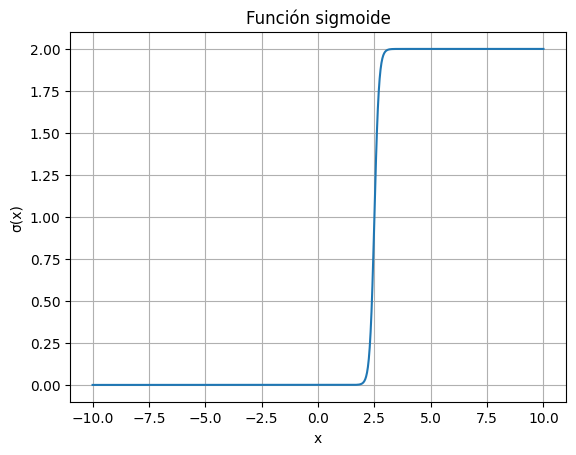

In [111]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid_k(x):
    k = 10 # que tan rápido crece la transición
    x0 = 2.5 # punto de activación - umbral # control de reposo
    valor_min = 0
    valor_max = 2
    s = 1 / (1 + np.exp(-k*(x-x0)))
    return valor_min + (valor_max - valor_min) * s

x = np.linspace(-10, 10, 1000)
y = sigmoid_k(x)

plt.figure()
plt.plot(x, y)
plt.xlabel("x")
plt.ylabel("σ(x)")
plt.title("Función sigmoide")
plt.grid(True)
plt.show()

# Criterio de eleccion de ruido
# ACC_TH  ≈ 3σ_acc
# GYRO_TH ≈ 3σ_gyro

In [112]:
y = 1 / (1+((np.e)**-2.5))
y

0.9241418199787566

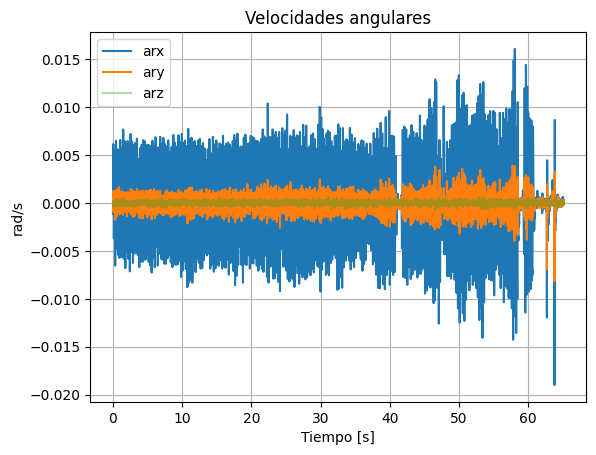

array([-0.00112747,  0.00113059,  0.0031449 , ...,  0.00013963,
        0.00015868,  0.00016773], shape=(6518,))

In [113]:
plt.figure()
plt.plot(t, df_u["arx"], label="arx")
plt.plot(t, df_u["ary"], label="ary")
# plt.plot(t, alx, label='ax original', alpha=0.4)
plt.plot(t, df_u["arz"], label="arz", alpha=0.4)
plt.xlabel("Tiempo [s]")
plt.ylabel("rad/s")
plt.legend()
plt.grid(True)
plt.title("Velocidades angulares")
plt.show()

arx_f	

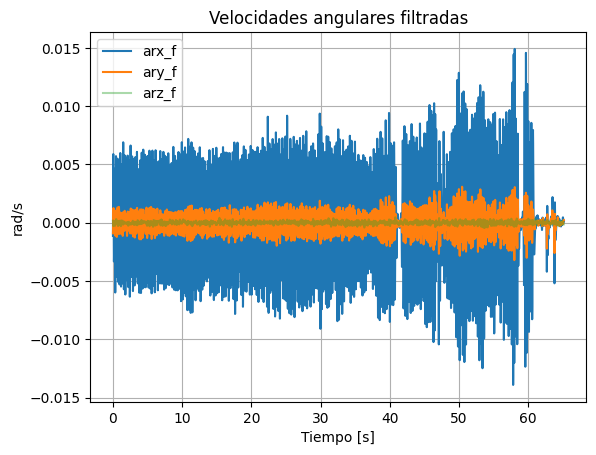

In [114]:
plt.figure()
plt.plot(t, df_u["arx_f"], label="arx_f")
plt.plot(t, df_u["ary_f"], label="ary_f")
# plt.plot(t, alx, label='ax original', alpha=0.4)
plt.plot(t, df_u["arz_f"], label="arz_f", alpha=0.4)
plt.xlabel("Tiempo [s]")
plt.ylabel("rad/s")
plt.legend()
plt.grid(True)
plt.title("Velocidades angulares filtradas")
plt.show()

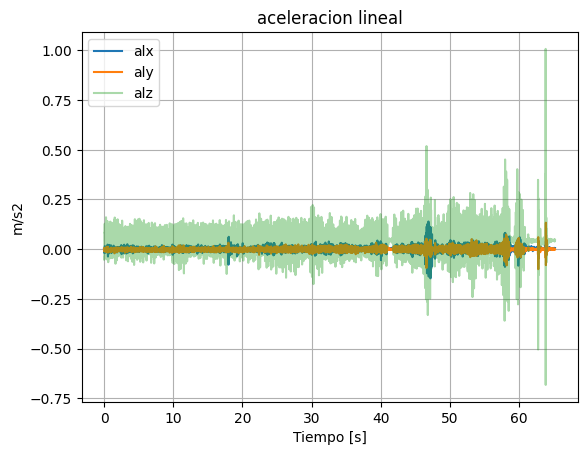

In [115]:
plt.figure()
plt.plot(t, df_u["alx"], label="alx")
plt.plot(t, df_u["aly"], label="aly")
# plt.plot(t, alx, label='ax original', alpha=0.4)
plt.plot(t, df_u["alz"], label="alz", alpha=0.4)
plt.xlabel("Tiempo [s]")
plt.ylabel("m/s2")
plt.legend()
plt.grid(True)
plt.title("aceleracion lineal")
plt.show()

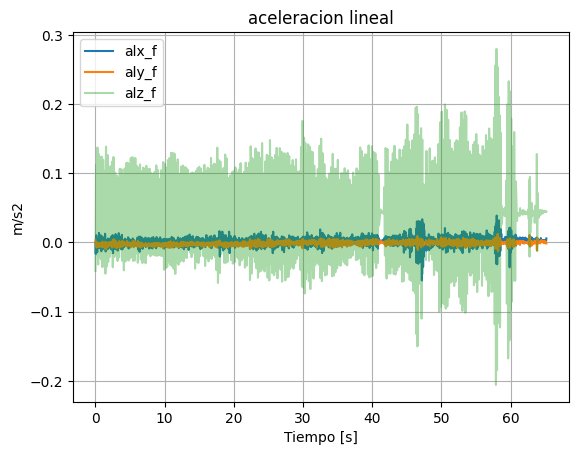

In [116]:
plt.figure()
plt.plot(t, df_u["alx_f"], label="alx_f")
plt.plot(t, df_u["aly_f"], label="aly_f")
# plt.plot(t, alx, label='ax original', alpha=0.4)
plt.plot(t, df_u["alz_f"], label="alz_f", alpha=0.4)
plt.xlabel("Tiempo [s]")
plt.ylabel("m/s2")
plt.legend()
plt.grid(True)
plt.title("aceleracion lineal")
plt.show()

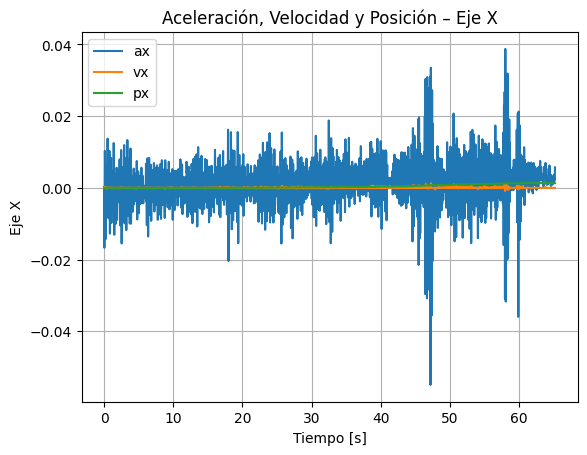

In [117]:
plt.figure()
plt.plot(t, df_u["alx_f"], label="ax")
plt.plot(t, df_u["vx"], label="vx")
plt.plot(t, df_u["px"], label="px")
plt.xlabel("Tiempo [s]")
plt.ylabel("Eje X")
plt.legend()
plt.grid(True)
plt.title("Aceleración, Velocidad y Posición – Eje X")
plt.show()

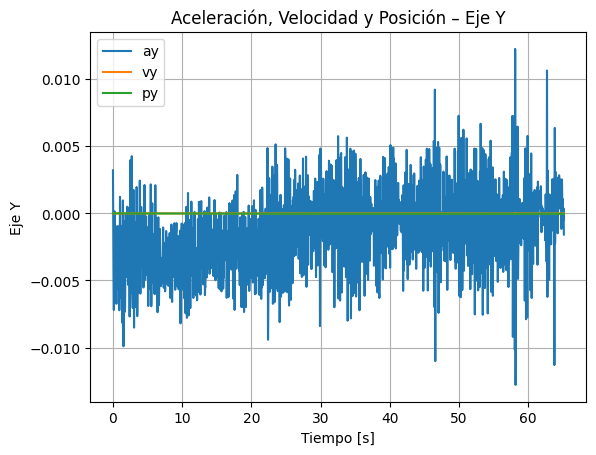

In [118]:
plt.figure()
plt.plot(t, df_u["aly_f"], label="ay")
plt.plot(t, df_u["vy"], label="vy")
plt.plot(t, df_u["py"], label="py")
plt.xlabel("Tiempo [s]")
plt.ylabel("Eje Y")
plt.legend()
plt.grid(True)
plt.title("Aceleración, Velocidad y Posición – Eje Y")
plt.show()

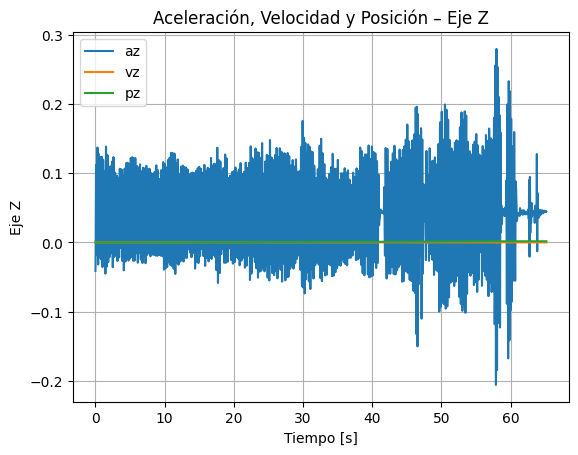

In [119]:
plt.figure()
plt.plot(t, df_u["alz_f"], label="az")
plt.plot(t, df_u["vz"], label="vz")
plt.plot(t, df_u["pz"], label="pz")
plt.xlabel("Tiempo [s]")
plt.ylabel("Eje Z")
plt.legend()
plt.grid(True)
plt.title("Aceleración, Velocidad y Posición – Eje Z")
plt.show()

In [120]:
a = df_u.loc[5, ["alx", "aly", "alz"]].values
norm = np.linalg.norm(a)
a_norm = a / np.linalg.norm(a)
print(a)
print(norm)
print(a_norm)
print(a[0], abs(a[0]))

[-0.01965248  0.00498932  0.04599007]
0.05026131773777162
[-0.39100611  0.0992675   0.91501923]
-0.0196524821221828 0.0196524821221828


In [121]:
# # ZUPT parcial

# EPS_ACCEL = 0.1      # m/s^2
# VAR_ACCEL = 0.02     # (m/s^2)^2
# MIN_SAMPLES = int(1.0 * fs)

# zupt = np.zeros(len(accel_filt), dtype=bool)
# counter = 0

# for k in range(N, len(accel_filt)):
#     acc_win = accel_filt[k-N:k]
    
#     acc_var = np.mean(np.var(acc_win, axis=0))
#     acc_dev = abs(acc_norm[k] - g)

#     stationary = (
#         acc_dev < EPS_ACCEL and
#         acc_var < VAR_ACCEL
#     )

#     if stationary:
#         counter += 1
#         if counter >= MIN_SAMPLES:
#             zupt[k] = True
#     else:
#         counter = 0

In [122]:
# # magnitud total del ZUPT

# acc_mag = np.sqrt(ax**2 + ay**2 + az**2)
# acc_mag_f = np.sqrt(ax_f**2 + ay_f**2 + az_f**2)

# plt.figure(figsize=(12,6))
# plt.plot(t, acc_mag, label='|a| original', alpha=0.4)
# plt.plot(t, acc_mag_f, label='|a| filtrado', linewidth=2)
# plt.axhline(9.81, color='k', linestyle='--', label='g')
# plt.legend()
# plt.grid()
# plt.title("Magnitud de aceleración")
# plt.show()

In [123]:
# Diseño de umbrales para ZUPT (criterio práctico)

# ZUPT no se diseña “a ojo”, se basa en:

# Aceleración cerca de g

# Baja varianza

# Giroscopio bajo (si lo tienes)

# Umbrales típicos (100 Hz)
# Variable	Umbral típico
# |a| − g	< 0.05 – 0.15 m/s²
# σ(a) ventana	< 0.02 – 0.05 m/s²
# |ω|	< 0.5 – 2 deg/s
# Ventana	0.2 – 0.5 s

In [124]:
# Eso es ingeniería bien hecha:

# FFT → identificar banda útil

# Allan → ruido y bias

# Datos reales → ajustar fc y umbrales

In [125]:
# from scipy.signal import sosfilt

# # gyro_filt = sosfilt(sos, gyro_raw)
# accel_filt = sosfilt(sos, accel_raw)

In [126]:
# from scipy.signal import sosfiltfilt

# gyro_filt = sosfiltfilt(sos, gyro_raw)